In [1]:
import numpy as np
import pandas as pd
#list of useful imports that  I will use
%matplotlib inline
#import os

import matplotlib.pyplot as plt
import pandas as pd
#import cv2
import numpy as np
#from glob import glob
import seaborn as sns
import random
import pickle

from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

In [3]:
df=pd.read_csv(r"C:\Users\HARIHARAN\Music\project\DATASET\Transaction_fraud.csv")
df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,debit,272.0,87.0,48.0,NaN,NaN,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,debit,204.0,87.0,NaN,NaN,gmail.com,NaN
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,debit,231.0,87.0,NaN,NaN,gmail.com,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,debit,387.0,87.0,3.0,NaN,aol.com,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   TransactionID   590540 non-null  int64  
 1   isFraud         590540 non-null  int64  
 2   TransactionDT   590540 non-null  int64  
 3   TransactionAmt  590540 non-null  float64
 4   ProductCD       590540 non-null  object 
 5   card1           590540 non-null  int64  
 6   card2           581607 non-null  float64
 7   card3           588975 non-null  float64
 8   card4           588963 non-null  object 
 9   card5           586281 non-null  float64
 10  card6           588969 non-null  object 
 11  addr1           524834 non-null  float64
 12  addr2           524834 non-null  float64
 13  dist1           238269 non-null  float64
 14  dist2           37627 non-null   float64
 15  P_emaildomain   496084 non-null  object 
 16  R_emaildomain   137291 non-null  object 
dtypes: float64

In [5]:
# Assuming your DataFrame is named df
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_columns].corr()

print(correlation_matrix)


                TransactionID   isFraud  TransactionDT  TransactionAmt  \
TransactionID        1.000000  0.014166       0.998280        0.012025   
isFraud              0.014166  1.000000       0.013103        0.011320   
TransactionDT        0.998280  0.013103       1.000000        0.011920   
TransactionAmt       0.012025  0.011320       0.011920        1.000000   
card1                0.010122 -0.013640       0.010625       -0.005725   
card2               -0.019900  0.003388      -0.019202        0.016136   
card3               -0.010091  0.154151      -0.011222       -0.109785   
card5               -0.023900 -0.033580      -0.024132        0.003061   
addr1               -0.000370  0.005596      -0.000051       -0.007421   
addr2                0.057213 -0.030387       0.051972        0.028312   
dist1               -0.027043  0.021522      -0.027295        0.026146   
dist2               -0.026273 -0.019054      -0.026860        0.023143   

                   card1     card2   

In [6]:
#df.columns.to_list()

In [7]:
df.shape

(590540, 17)

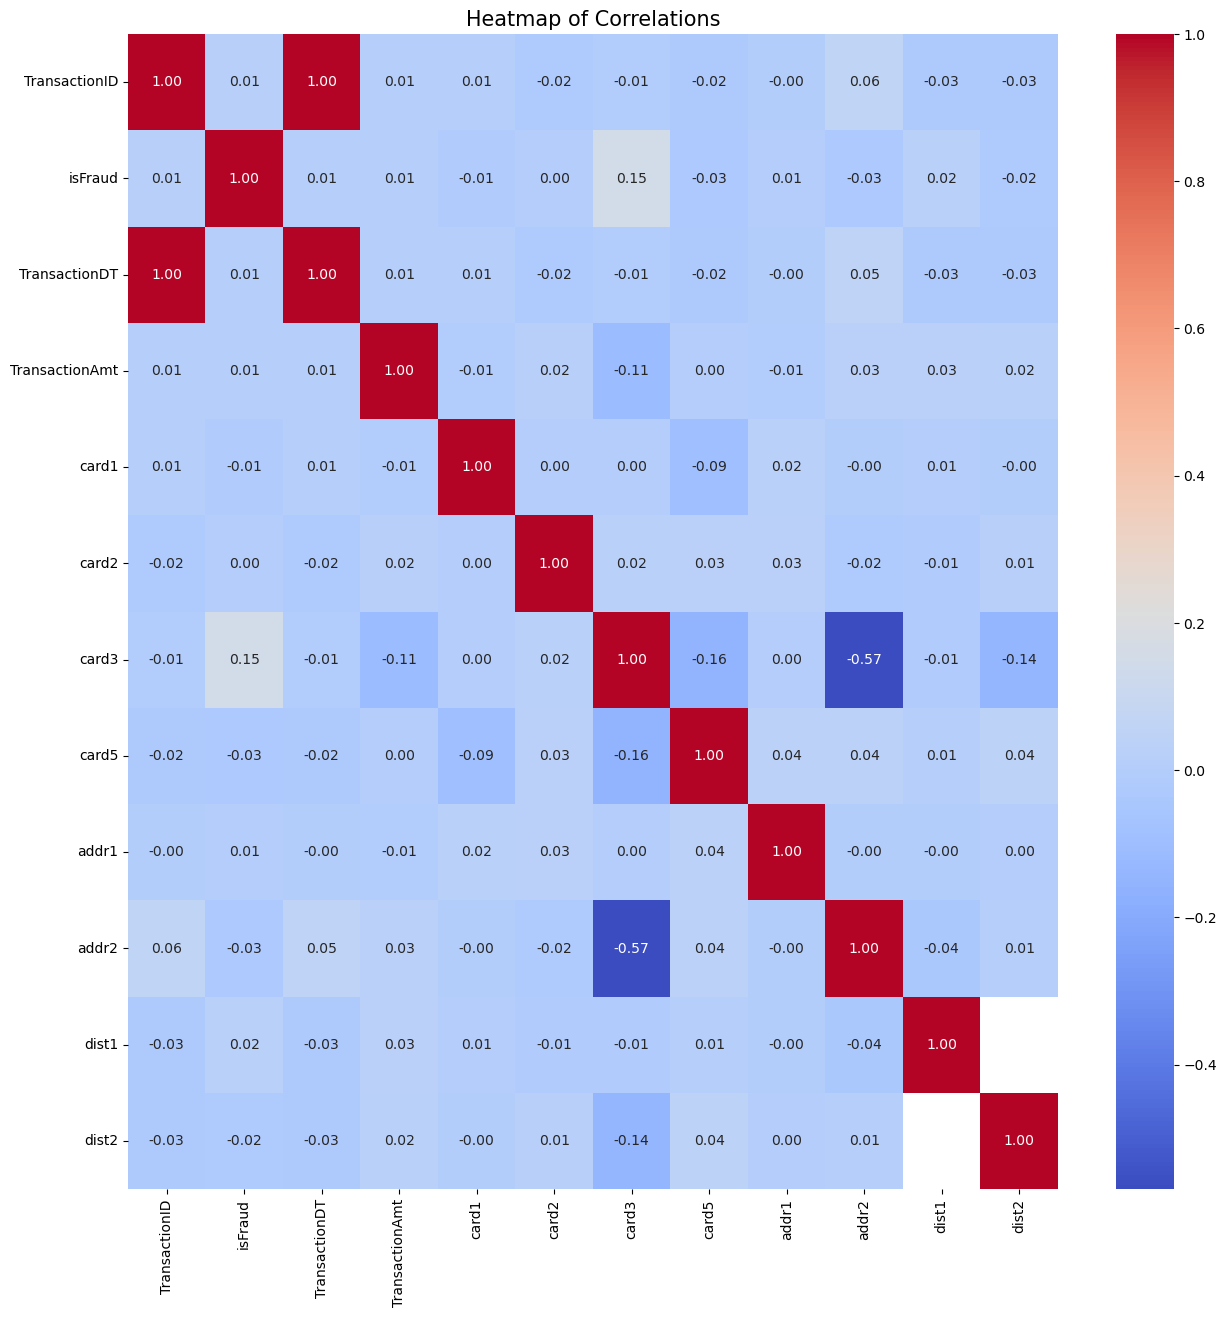

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap for better visualization
plt.figure(figsize=(15,15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of Correlations',fontsize=15)
plt.show()


In [9]:
df["ProductCD"].unique()

array(['W', 'H', 'C', 'S', 'R'], dtype=object)

In [10]:
df["card4"].unique()

array(['discover', 'mastercard', 'visa', 'american express', nan],
      dtype=object)

In [11]:
df["card6"].unique()

array(['credit', 'debit', nan, 'debit or credit', 'charge card'],
      dtype=object)

In [12]:
df["P_emaildomain"].unique()

array([nan, 'gmail.com', 'outlook.com', 'yahoo.com', 'mail.com',
       'anonymous.com', 'hotmail.com', 'verizon.net', 'aol.com', 'me.com',
       'comcast.net', 'optonline.net', 'cox.net', 'charter.net',
       'rocketmail.com', 'prodigy.net.mx', 'embarqmail.com', 'icloud.com',
       'live.com.mx', 'gmail', 'live.com', 'att.net', 'juno.com',
       'ymail.com', 'sbcglobal.net', 'bellsouth.net', 'msn.com', 'q.com',
       'yahoo.com.mx', 'centurylink.net', 'servicios-ta.com',
       'earthlink.net', 'hotmail.es', 'cfl.rr.com', 'roadrunner.com',
       'netzero.net', 'gmx.de', 'suddenlink.net', 'frontiernet.net',
       'windstream.net', 'frontier.com', 'outlook.es', 'mac.com',
       'netzero.com', 'aim.com', 'web.de', 'twc.com', 'cableone.net',
       'yahoo.fr', 'yahoo.de', 'yahoo.es', 'sc.rr.com', 'ptd.net',
       'live.fr', 'yahoo.co.uk', 'hotmail.fr', 'hotmail.de',
       'hotmail.co.uk', 'protonmail.com', 'yahoo.co.jp'], dtype=object)

In [13]:
df["isFraud"].unique()

array([0, 1])

In [14]:
df.isnull().sum()

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
card1                  0
card2               8933
card3               1565
card4               1577
card5               4259
card6               1571
addr1              65706
addr2              65706
dist1             352271
dist2             552913
P_emaildomain      94456
R_emaildomain     453249
dtype: int64

In [15]:
df["card4"].value_counts()

card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64

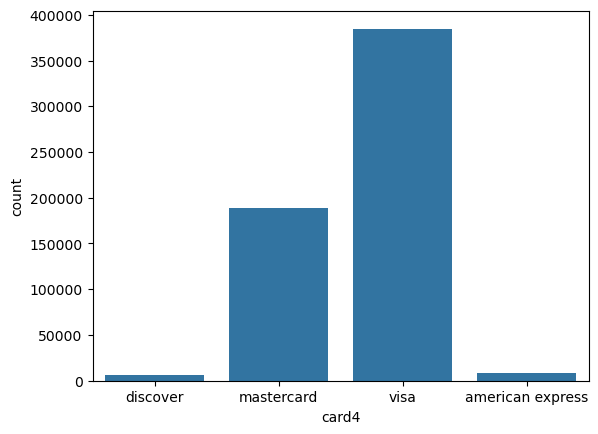

In [16]:
sns.countplot(x=df["card4"])
plt.show()

In [17]:
df["card6"].value_counts()

card6
debit              439938
credit             148986
debit or credit        30
charge card            15
Name: count, dtype: int64

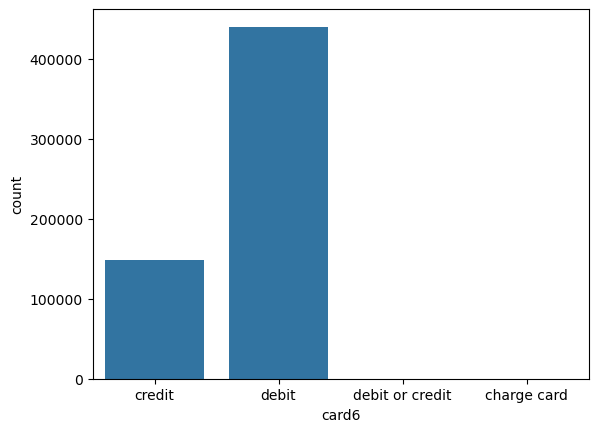

In [18]:
sns.countplot(x=df["card6"])
plt.show()

In [19]:
df["ProductCD"].value_counts()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

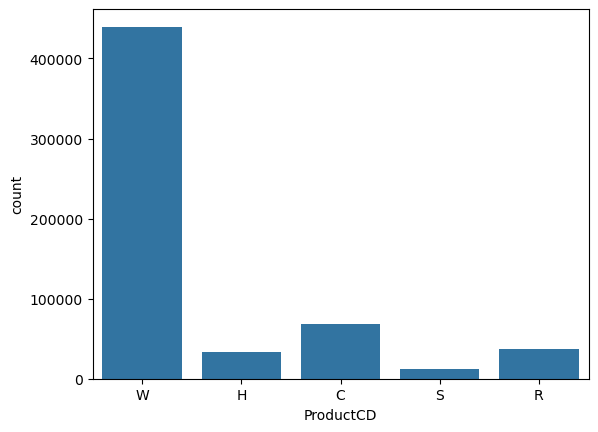

In [20]:
sns.countplot(x=df["ProductCD"])
plt.show()

In [21]:
df=df.drop(columns=["P_emaildomain","R_emaildomain"])
df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,debit,272.0,87.0,48.0,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,debit,204.0,87.0,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,debit,231.0,87.0,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,debit,387.0,87.0,3.0,NaN


In [22]:
df.isnull().sum()

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
card1                  0
card2               8933
card3               1565
card4               1577
card5               4259
card6               1571
addr1              65706
addr2              65706
dist1             352271
dist2             552913
dtype: int64

In [24]:
df["card3"].fillna(df["card3"].mean(),inplace=True)
df

C:\Users\HARIHARAN\AppData\Local\Temp\ipykernel_24204\976338753.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["card3"].fillna(df["card3"].mean(),inplace=True)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2
0,2987000,0,86400,68.50,W,13926,362.555488,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN
1,2987001,0,86401,29.00,W,2755,404.000000,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.000000,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN
3,2987003,0,86499,50.00,W,18132,567.000000,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.000000,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,362.555488,150.0,visa,226.0,debit,272.0,87.0,48.0,NaN
590536,3577536,0,15811049,39.50,W,10444,225.000000,150.0,mastercard,224.0,debit,204.0,87.0,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.000000,150.0,mastercard,224.0,debit,231.0,87.0,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.000000,150.0,mastercard,224.0,debit,387.0,87.0,3.0,NaN


In [25]:
df["card5"].fillna(df["card5"].mean(),inplace=True)
df

C:\Users\HARIHARAN\AppData\Local\Temp\ipykernel_24204\2990276331.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["card5"].fillna(df["card5"].mean(),inplace=True)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2
0,2987000,0,86400,68.50,W,13926,362.555488,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN
1,2987001,0,86401,29.00,W,2755,404.000000,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.000000,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN
3,2987003,0,86499,50.00,W,18132,567.000000,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.000000,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,362.555488,150.0,visa,226.0,debit,272.0,87.0,48.0,NaN
590536,3577536,0,15811049,39.50,W,10444,225.000000,150.0,mastercard,224.0,debit,204.0,87.0,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.000000,150.0,mastercard,224.0,debit,231.0,87.0,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.000000,150.0,mastercard,224.0,debit,387.0,87.0,3.0,NaN


In [26]:
df["card4"].fillna(df["card4"].mode()[0],inplace=True)
df

C:\Users\HARIHARAN\AppData\Local\Temp\ipykernel_24204\4004429747.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["card4"].fillna(df["card4"].mode()[0],inplace=True)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2
0,2987000,0,86400,68.50,W,13926,362.555488,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN
1,2987001,0,86401,29.00,W,2755,404.000000,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.000000,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN
3,2987003,0,86499,50.00,W,18132,567.000000,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.000000,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,362.555488,150.0,visa,226.0,debit,272.0,87.0,48.0,NaN
590536,3577536,0,15811049,39.50,W,10444,225.000000,150.0,mastercard,224.0,debit,204.0,87.0,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.000000,150.0,mastercard,224.0,debit,231.0,87.0,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.000000,150.0,mastercard,224.0,debit,387.0,87.0,3.0,NaN


In [27]:
df["card6"].fillna(df["card6"].mode()[0],inplace=True)
df

C:\Users\HARIHARAN\AppData\Local\Temp\ipykernel_24204\1386403824.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["card6"].fillna(df["card6"].mode()[0],inplace=True)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2
0,2987000,0,86400,68.50,W,13926,362.555488,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN
1,2987001,0,86401,29.00,W,2755,404.000000,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.000000,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN
3,2987003,0,86499,50.00,W,18132,567.000000,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.000000,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,362.555488,150.0,visa,226.0,debit,272.0,87.0,48.0,NaN
590536,3577536,0,15811049,39.50,W,10444,225.000000,150.0,mastercard,224.0,debit,204.0,87.0,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.000000,150.0,mastercard,224.0,debit,231.0,87.0,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.000000,150.0,mastercard,224.0,debit,387.0,87.0,3.0,NaN


In [28]:
df["addr1"].unique()

array([315., 325., 330., 476., 420., 272., 126., 337., 204.,  nan, 226.,
       170., 184., 264., 299., 441., 472., 251., 469., 191., 485., 122.,
       220., 205., 387., 181., 231., 436., 327., 343., 123., 502., 269.,
       158., 433., 143., 225., 492., 177., 512., 310., 308., 418., 494.,
       253., 428., 203., 110., 444., 498., 194., 536., 384., 324., 295.,
       448., 157., 171., 224., 491., 274., 432., 459., 106., 296., 254.,
       452., 347., 335., 305., 161., 221., 154., 130., 465., 451., 331.,
       511., 486., 312., 242., 131., 508., 332., 283., 216., 431., 391.,
       333., 496., 304., 167., 261., 399., 164., 142., 393., 258., 375.,
       483., 404., 482., 148., 218., 127., 403., 374., 477., 478., 241.,
       504., 453., 535., 100., 239., 152., 500., 356., 198., 162., 244.,
       520., 531., 401., 427., 352., 540., 456., 371., 409., 529., 505.,
       503., 346., 359., 499., 298., 190., 454., 172., 145., 493., 119.,
       521., 270., 395., 366., 348., 313., 338., 13

In [29]:
df["addr1"].fillna(df["addr1"].mean(),inplace=True)
df

C:\Users\HARIHARAN\AppData\Local\Temp\ipykernel_24204\301918749.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["addr1"].fillna(df["addr1"].mean(),inplace=True)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2
0,2987000,0,86400,68.50,W,13926,362.555488,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN
1,2987001,0,86401,29.00,W,2755,404.000000,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.000000,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN
3,2987003,0,86499,50.00,W,18132,567.000000,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.000000,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,362.555488,150.0,visa,226.0,debit,272.0,87.0,48.0,NaN
590536,3577536,0,15811049,39.50,W,10444,225.000000,150.0,mastercard,224.0,debit,204.0,87.0,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.000000,150.0,mastercard,224.0,debit,231.0,87.0,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.000000,150.0,mastercard,224.0,debit,387.0,87.0,3.0,NaN


In [30]:
df["addr2"].unique()

array([ 87.,  nan,  96.,  35.,  60.,  98.,  43.,  65.,  32.,  13.,  31.,
       101.,  24.,  16.,  15.,  19.,  71.,  59., 102.,  44.,  26.,  69.,
        47.,  78.,  88.,  66.,  72.,  22.,  57.,  25.,  17.,  30.,  29.,
        21.,  14.,  49.,  83.,  75.,  34.,  86.,  48.,  68.,  23.,  70.,
        62.,  54.,  50.,  52.,  39.,  76.,  10.,  73.,  97.,  63.,  27.,
        28.,  38.,  74.,  77.,  92.,  79.,  84.,  82.,  40.,  36.,  46.,
        18.,  20.,  89.,  61.,  94., 100.,  55.,  51.,  93.])

In [31]:
df["addr2"].fillna(df["addr2"].mean(),inplace=True)
df

C:\Users\HARIHARAN\AppData\Local\Temp\ipykernel_24204\1952530987.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["addr2"].fillna(df["addr2"].mean(),inplace=True)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2
0,2987000,0,86400,68.50,W,13926,362.555488,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN
1,2987001,0,86401,29.00,W,2755,404.000000,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.000000,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN
3,2987003,0,86499,50.00,W,18132,567.000000,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.000000,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,362.555488,150.0,visa,226.0,debit,272.0,87.0,48.0,NaN
590536,3577536,0,15811049,39.50,W,10444,225.000000,150.0,mastercard,224.0,debit,204.0,87.0,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.000000,150.0,mastercard,224.0,debit,231.0,87.0,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.000000,150.0,mastercard,224.0,debit,387.0,87.0,3.0,NaN


In [32]:
df=df.drop(columns=["dist1","dist2"])
df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2
0,2987000,0,86400,68.50,W,13926,362.555488,150.0,discover,142.0,credit,315.0,87.0
1,2987001,0,86401,29.00,W,2755,404.000000,150.0,mastercard,102.0,credit,325.0,87.0
2,2987002,0,86469,59.00,W,4663,490.000000,150.0,visa,166.0,debit,330.0,87.0
3,2987003,0,86499,50.00,W,18132,567.000000,150.0,mastercard,117.0,debit,476.0,87.0
4,2987004,0,86506,50.00,H,4497,514.000000,150.0,mastercard,102.0,credit,420.0,87.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,362.555488,150.0,visa,226.0,debit,272.0,87.0
590536,3577536,0,15811049,39.50,W,10444,225.000000,150.0,mastercard,224.0,debit,204.0,87.0
590537,3577537,0,15811079,30.95,W,12037,595.000000,150.0,mastercard,224.0,debit,231.0,87.0
590538,3577538,0,15811088,117.00,W,7826,481.000000,150.0,mastercard,224.0,debit,387.0,87.0


In [33]:
df.isnull().sum()

TransactionID     0
isFraud           0
TransactionDT     0
TransactionAmt    0
ProductCD         0
card1             0
card2             0
card3             0
card4             0
card5             0
card6             0
addr1             0
addr2             0
dtype: int64

In [34]:
df["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

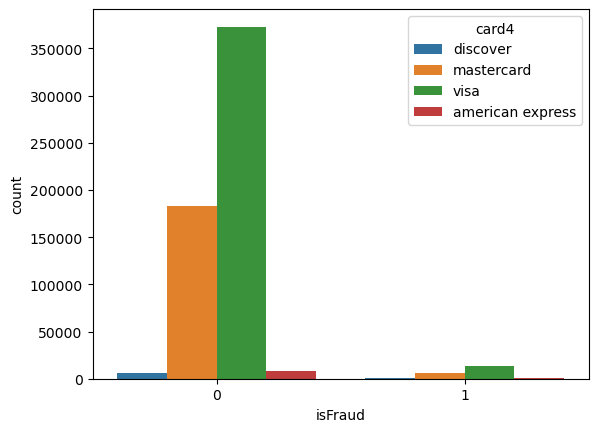

In [35]:
sns.countplot(x=df["isFraud"],hue=df['card4'])
plt.show()

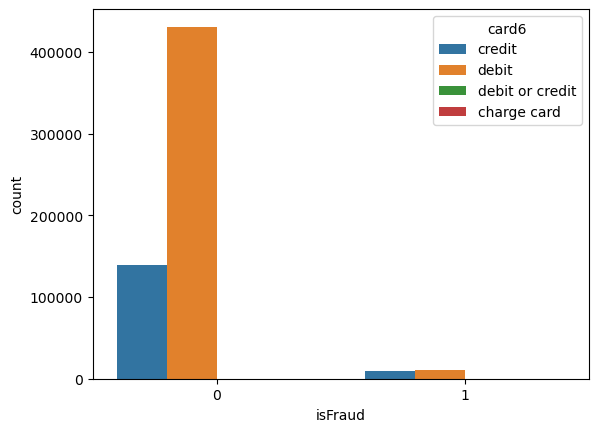

In [36]:
sns.countplot(x=df["isFraud"],hue=df['card6'])
plt.show()

In [37]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [38]:
df['card4']=le.fit_transform(df['card4'])
df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2
0,2987000,0,86400,68.50,W,13926,362.555488,150.0,1,142.0,credit,315.0,87.0
1,2987001,0,86401,29.00,W,2755,404.000000,150.0,2,102.0,credit,325.0,87.0
2,2987002,0,86469,59.00,W,4663,490.000000,150.0,3,166.0,debit,330.0,87.0
3,2987003,0,86499,50.00,W,18132,567.000000,150.0,2,117.0,debit,476.0,87.0
4,2987004,0,86506,50.00,H,4497,514.000000,150.0,2,102.0,credit,420.0,87.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,362.555488,150.0,3,226.0,debit,272.0,87.0
590536,3577536,0,15811049,39.50,W,10444,225.000000,150.0,2,224.0,debit,204.0,87.0
590537,3577537,0,15811079,30.95,W,12037,595.000000,150.0,2,224.0,debit,231.0,87.0
590538,3577538,0,15811088,117.00,W,7826,481.000000,150.0,2,224.0,debit,387.0,87.0


In [39]:
df['card6']=le.fit_transform(df['card6'])
df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2
0,2987000,0,86400,68.50,W,13926,362.555488,150.0,1,142.0,1,315.0,87.0
1,2987001,0,86401,29.00,W,2755,404.000000,150.0,2,102.0,1,325.0,87.0
2,2987002,0,86469,59.00,W,4663,490.000000,150.0,3,166.0,2,330.0,87.0
3,2987003,0,86499,50.00,W,18132,567.000000,150.0,2,117.0,2,476.0,87.0
4,2987004,0,86506,50.00,H,4497,514.000000,150.0,2,102.0,1,420.0,87.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,362.555488,150.0,3,226.0,2,272.0,87.0
590536,3577536,0,15811049,39.50,W,10444,225.000000,150.0,2,224.0,2,204.0,87.0
590537,3577537,0,15811079,30.95,W,12037,595.000000,150.0,2,224.0,2,231.0,87.0
590538,3577538,0,15811088,117.00,W,7826,481.000000,150.0,2,224.0,2,387.0,87.0


In [40]:
df['ProductCD']=le.fit_transform(df['ProductCD'])
df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2
0,2987000,0,86400,68.50,4,13926,362.555488,150.0,1,142.0,1,315.0,87.0
1,2987001,0,86401,29.00,4,2755,404.000000,150.0,2,102.0,1,325.0,87.0
2,2987002,0,86469,59.00,4,4663,490.000000,150.0,3,166.0,2,330.0,87.0
3,2987003,0,86499,50.00,4,18132,567.000000,150.0,2,117.0,2,476.0,87.0
4,2987004,0,86506,50.00,1,4497,514.000000,150.0,2,102.0,1,420.0,87.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,4,6550,362.555488,150.0,3,226.0,2,272.0,87.0
590536,3577536,0,15811049,39.50,4,10444,225.000000,150.0,2,224.0,2,204.0,87.0
590537,3577537,0,15811079,30.95,4,12037,595.000000,150.0,2,224.0,2,231.0,87.0
590538,3577538,0,15811088,117.00,4,7826,481.000000,150.0,2,224.0,2,387.0,87.0


In [41]:
df = df.drop_duplicates()

In [42]:
from sklearn.utils import resample
# Separate majority and minority classes
df_majority = df[df['isFraud']== 0]
df_minority = df[df['isFraud']== 1]
 
# Downsample majority class and upsample the minority class
df_minority_upsampled = resample(df_minority, replace=True,n_samples=30000,random_state=100) 
df_majority_downsampled = resample(df_majority, replace=False,n_samples=30000,random_state=100) 
 
# Combine minority class with downsampled majority class
df_balanced = pd.concat([df_minority_upsampled, df_majority_downsampled])
 
# Display new class counts
df_balanced['isFraud'].value_counts()

isFraud
1    30000
0    30000
Name: count, dtype: int64

C:\Users\HARIHARAN\AppData\Local\Temp\ipykernel_24204\2366326274.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="isFraud", data=df_balanced, palette=sns.color_palette("cubehelix", 4))
C:\Users\HARIHARAN\AppData\Local\Temp\ipykernel_24204\2366326274.py:3: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.countplot(x="isFraud", data=df_balanced, palette=sns.color_palette("cubehelix", 4))


Text(0.5, 0, 'Class')

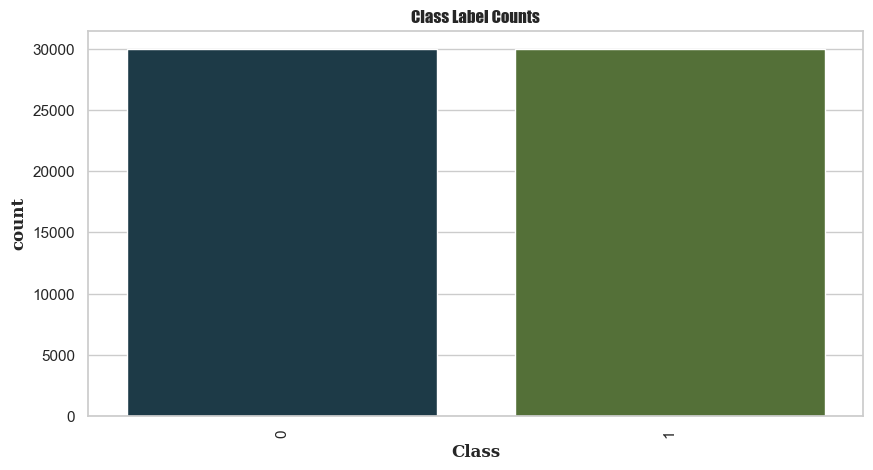

In [43]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 5))
ax = sns.countplot(x="isFraud", data=df_balanced, palette=sns.color_palette("cubehelix", 4))
plt.xticks(rotation=90)
plt.title("Class Label Counts", {"fontname":"fantasy", "fontweight":"bold", "fontsize":"medium"})
plt.ylabel("count", {"fontname": "serif", "fontweight":"bold"})
plt.xlabel("Class", {"fontname": "serif", "fontweight":"bold"}) 

In [44]:
df=df_balanced
df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2
193096,3180096,1,4328172,18.481,0,9120,500.000000,185.0,2,224.0,1,290.733794,86.80063
403975,3390975,1,10192806,29.000,4,4141,404.000000,150.0,2,102.0,1,264.000000,87.00000
358709,3345709,1,8889028,300.000,2,13526,529.000000,150.0,3,162.0,1,299.000000,87.00000
3907,2990907,1,160284,49.000,4,3507,362.555488,150.0,3,226.0,1,204.000000,87.00000
463460,3450460,1,11917859,50.000,1,12501,490.000000,150.0,3,226.0,2,204.000000,87.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
47461,3034461,0,1123683,72.000,4,16972,174.000000,150.0,3,226.0,2,269.000000,87.00000
63671,3050671,0,1448248,300.000,1,2889,555.000000,150.0,3,226.0,1,181.000000,87.00000
244262,3231262,0,5794299,34.000,4,8886,555.000000,150.0,3,226.0,1,181.000000,87.00000
216867,3203867,0,5068306,59.000,4,9303,298.000000,150.0,3,226.0,2,476.000000,87.00000


In [45]:
x = df.drop(columns=['isFraud'])
y = df['isFraud']

In [46]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=100)

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [47]:
from sklearn.decomposition import PCA
pca_model=PCA(n_components=0.95)
x_train=pca_model.fit_transform(x_train)
x_test=pca_model.transform(x_test)

In [50]:
pd.DataFrame(x_test).to_csv(r"C:\Users\HARIHARAN\Music\project\CODE\FRONTEND\test.csv",index=False)

In [51]:
x_train

array([[-0.7945786 , -1.9224505 ,  0.20871425, ...,  0.37526602,
        -0.12025848,  0.89772384],
       [-1.88936915,  2.22855013,  0.02395851, ..., -0.11305523,
         0.44971022, -1.04873234],
       [-2.11910584,  0.45154446,  1.06745649, ...,  1.21083872,
         1.09991747, -0.26612179],
       ...,
       [ 1.05538571, -0.91241041,  0.86752779, ...,  0.83768407,
        -0.66158236,  0.36125742],
       [ 0.33684691, -2.06171124,  0.75695354, ..., -0.10833216,
        -0.69807146,  0.35975616],
       [ 2.44353382,  1.25468986,  0.26561567, ...,  0.05407755,
         0.4647186 ,  0.21165096]], shape=(42000, 10))

# KNN

AUC on Test data is 0.8218888888888889
AUC on Train data is 0.9577619047619048
---------------------------


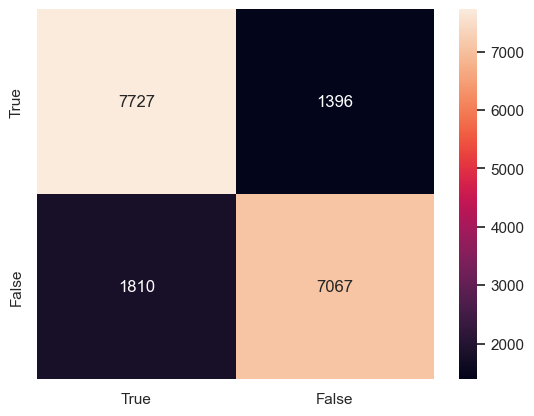

In [52]:
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=2,p=2)
knn_model.fit(x_train, y_train)

import pickle
filename = r'C:\Users\HARIHARAN\Music\project\CODE\FRONTEND\knn_Fraud.pkl'
pickle.dump(knn_model, open(filename, 'wb'))


pred_test2 =knn_model.predict(x_test)
test_accuracy2 = accuracy_score(y_test, pred_test2)
pred_train2 = knn_model.predict(x_train)
train_accuracy2 =accuracy_score(y_train,pred_train2)

print("AUC on Test data is " +str(accuracy_score(y_test,pred_test2)))
print("AUC on Train data is " +str(accuracy_score(y_train,pred_train2)))

print("---------------------------")

# Code for drawing seaborn heatmaps
class_names =['True','False']
df_heatmap = pd.DataFrame(confusion_matrix(y_test, pred_test2.round()), index=class_names, columns=class_names )
fig = plt.figure( )
heatmap = sns.heatmap(df_heatmap, annot=True, fmt="d")

# LogisticRegression

AUC on Test data is 0.6790555555555555
AUC on Train data is 0.6725476190476191
---------------------------


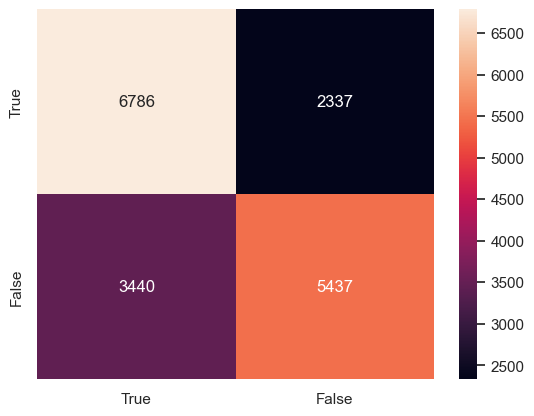

In [53]:
from sklearn.linear_model import LogisticRegression 
log_model=LogisticRegression()
log_model.fit(x_train,y_train)

import pickle
filename = r'C:\Users\HARIHARAN\Music\project\CODE\FRONTEND\LR_Fraud.pkl'
pickle.dump(log_model, open(filename, 'wb'))


pred_test1 =log_model.predict(x_test)
test_accuracy1 = accuracy_score(y_test, pred_test1)
pred_train = log_model.predict(x_train)
train_accuracy1 =accuracy_score(y_train,pred_train)




print("AUC on Test data is " +str(accuracy_score(y_test,pred_test1)))
print("AUC on Train data is " +str(accuracy_score(y_train,pred_train)))

print("---------------------------")

# Code for drawing seaborn heatmaps
class_names =['True','False']
df_heatmap = pd.DataFrame(confusion_matrix(y_test, pred_test1.round()), index=class_names, columns=class_names )
fig = plt.figure( )
heatmap = sns.heatmap(df_heatmap, annot=True, fmt="d")

# DecisionTreeClassifier

In [54]:
from sklearn.tree import DecisionTreeClassifier

dept = [1, 5, 10, 50, 100, 500,800, 1000]
min_samples =  [5, 10, 100, 500]


param_grid={'min_samples_split':min_samples , 'max_depth':dept}
clf = DecisionTreeClassifier()
model = GridSearchCV(clf,param_grid,scoring='accuracy',n_jobs=-1,cv=3)
model.fit(x_train,y_train)
print("optimal min_samples_split",model.best_estimator_.min_samples_split)
print("optimal max_depth",model.best_estimator_.max_depth)

optimal min_samples_split 5
optimal max_depth 500


AUC on Test data is 0.8293888888888888
AUC on Train data is 0.9864761904761905
---------------------------


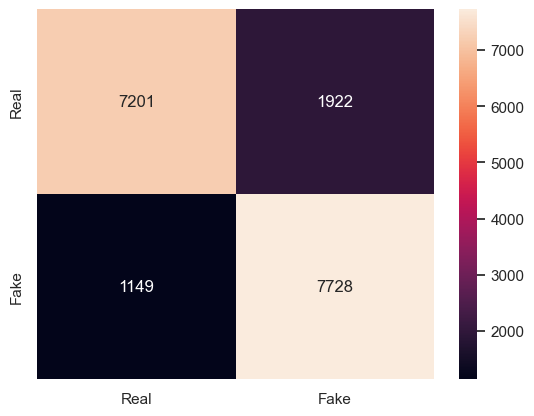

In [56]:
from sklearn.metrics import accuracy_score
dt = DecisionTreeClassifier(criterion='entropy',splitter='best',max_depth =1000,min_samples_split =5)
dt.fit(x_train,y_train)

import pickle
filename = r'C:\Users\HARIHARAN\Music\project\CODE\FRONTEND\dt_Fraud.pkl'
pickle.dump(dt, open(filename, 'wb'))

pred_test2 =dt.predict(x_test)
test_accuracy2 = accuracy_score(y_test, pred_test2)
pred_train = dt.predict(x_train)
train_accuracy2 =accuracy_score(y_train,pred_train)



print("AUC on Test data is " +str(accuracy_score(y_test,pred_test2)))
print("AUC on Train data is " +str(accuracy_score(y_train,pred_train)))

print("---------------------------")

# Code for drawing seaborn heatmaps
class_names =['Real','Fake']
df_heatmap = pd.DataFrame(confusion_matrix(y_test, pred_test2.round()), index=class_names, columns=class_names )
fig = plt.figure( )
heatmap = sns.heatmap(df_heatmap, annot=True, fmt="d")

# RandomForestClassifier

In [58]:
from sklearn.ensemble import RandomForestClassifier

dept = [1, 5, 10, 50, 100, 500, 1000]
n_estimators =  [20, 40, 60, 80, 100, 120]

param_grid={'n_estimators':n_estimators , 'max_depth':dept}
clf = RandomForestClassifier()
model = GridSearchCV(clf,param_grid,scoring='accuracy',n_jobs=-1,cv=5)
model.fit(x_train,y_train)
print("optimal n_estimators",model.best_estimator_.n_estimators)
print("optimal max_depth",model.best_estimator_.max_depth)
optimal_max_depth = model.best_estimator_.max_depth
optimal_n_estimators = model.best_estimator_.n_estimators

optimal n_estimators 100
optimal max_depth 500


AUC on Test data is 0.8903888888888889
AUC on Train data is 1.0
---------------------------


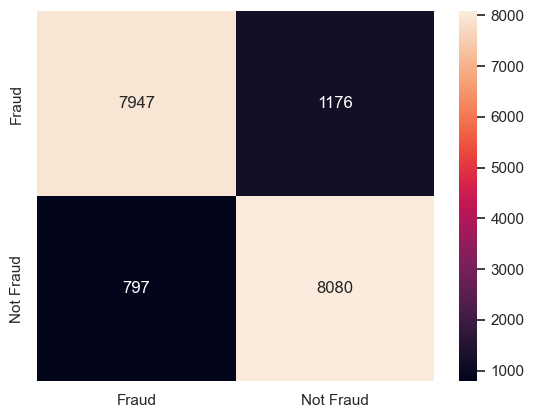

In [59]:
from sklearn.metrics import accuracy_score
#training our model for max_depth=100,n_estimators = 120
clf = RandomForestClassifier(max_depth = optimal_max_depth,n_estimators = optimal_n_estimators)
clf.fit(x_train,y_train)

import pickle
filename = r'C:\Users\HARIHARAN\Music\project\CODE\FRONTEND\rf_Fraud.pkl'
pickle.dump(clf, open(filename, 'wb'))


pred_test3 =clf.predict(x_test)
test_accuracy3 = accuracy_score(y_test, pred_test3)
pred_train = clf.predict(x_train)
train_accuracy3 =accuracy_score(y_train,pred_train)

print("AUC on Test data is " +str(accuracy_score(y_test,pred_test3)))
print("AUC on Train data is " +str(accuracy_score(y_train,pred_train)))

print("---------------------------")

# Code for drawing seaborn heatmaps
class_names =['Fraud','Not Fraud']
df_heatmap = pd.DataFrame(confusion_matrix(y_test, pred_test3.round()), index=class_names, columns=class_names )
fig = plt.figure( )
heatmap = sns.heatmap(df_heatmap, annot=True, fmt="d")

# XG Boost

AUC on Test data is 0.836
AUC on Train data is 0.9349047619047619
---------------------------


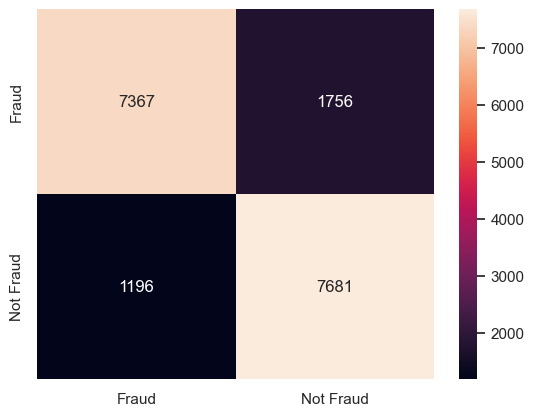

In [61]:
import xgboost as xgb
#import lightgbm as lgb
from sklearn.metrics import accuracy_score

model = xgb.XGBClassifier(n_estimators=150, learning_rate=0.5,random_state=20)
model.fit(x_train, y_train)

import pickle
filename = r'C:\Users\HARIHARAN\Music\project\CODE\FRONTEND\X_gb_Fraud.pkl'
pickle.dump(model, open(filename, 'wb'))

pred_test4 =model.predict(x_test)
test_accuracy4 = accuracy_score(y_test, pred_test4)
pred_train = model.predict(x_train)
train_accuracy4 =accuracy_score(y_train,pred_train)

print("AUC on Test data is " +str(accuracy_score(y_test,pred_test4)))
print("AUC on Train data is " +str(accuracy_score(y_train,pred_train)))

print("---------------------------")

# Code for drawing seaborn heatmaps
class_names =['Fraud','Not Fraud']
df_heatmap = pd.DataFrame(confusion_matrix(y_test, pred_test4.round()), index=class_names, columns=class_names )
fig = plt.figure( )
heatmap = sns.heatmap(df_heatmap, annot=True, fmt="d")

# SVC

AUC on Test data is 0.7196666666666667
AUC on Train data is 0.7212142857142857
---------------------------


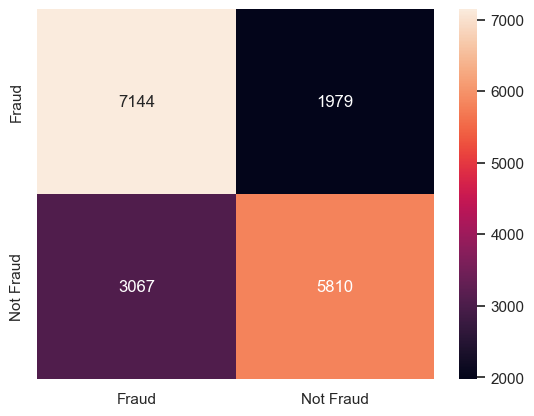

In [62]:
from sklearn.svm import SVC
svm_model=SVC(kernel='rbf',degree=2)
svm_model.fit(x_train,y_train)

import pickle
filename = r'C:\Users\HARIHARAN\Music\project\CODE\FRONTEND\svc_fraud.pkl'
pickle.dump(svm_model, open(filename, 'wb'))

pred_test3 =svm_model.predict(x_test)
test_accuracy3 = accuracy_score(y_test, pred_test3)
pred_train3 = svm_model.predict(x_train)
train_accuracy3 =accuracy_score(y_train,pred_train3)

print("AUC on Test data is " +str(accuracy_score(y_test,pred_test3)))
print("AUC on Train data is " +str(accuracy_score(y_train,pred_train3)))

print("---------------------------")

# Code for drawing seaborn heatmaps
class_names =['Fraud','Not Fraud']
df_heatmap = pd.DataFrame(confusion_matrix(y_test, pred_test3.round()), index=class_names, columns=class_names )
fig = plt.figure( )
heatmap = sns.heatmap(df_heatmap, annot=True, fmt="d")